#**스마트폰 센서 데이터 기반 모션 분류**


## 1.설정

* 구글 드라이브 연결

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (1) 라이브러리 불러오기

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam

In [12]:
# 학습곡선 함수
def dl_history_plot(history):
    plt.figure(figsize=(10,6))
    plt.plot(history['loss'], label='train_err', marker = '.')
    plt.plot(history['val_loss'], label='val_err', marker = '.')

    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()

### (2) 데이터 불러오기

* 주어진 데이터셋
    * data01_train.csv : 학습 및 검증용
    * data01_test.csv : 테스트용
    * feature.csv : feature 이름을 계층구조로 정리한 데이터

### (3) 데이터로딩

In [13]:
# 주어진 데이터 셋을 불러오세요.(3개)
data01_train = pd.read_csv('data01_train.csv')
data01_test = pd.read_csv('data01_test.csv')
feature_list = pd.read_csv('features.csv')

In [14]:
#불필요한 칼럼을 삭제하세요.
data01_train.drop('subject', axis = 1, inplace = True)
data01_test.drop('subject', axis = 1, inplace = True)

### (4) 기본 정보 조회

In [15]:
#전체 데이터의 행,열 개수 확인
data01_train.shape

(5881, 562)

In [16]:
data01_test.shape

(1471, 562)

In [17]:
# 전체 데이터의 상위 5개 행 확인
data01_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288508,-0.009196,-0.103362,-0.988986,-0.962797,-0.967422,-0.989000,-0.962596,-0.965650,-0.929747,...,-0.487737,-0.816696,-0.042494,-0.044218,0.307873,0.072790,-0.601120,0.331298,0.165163,STANDING
1,0.265757,-0.016576,-0.098163,-0.989551,-0.994636,-0.987435,-0.990189,-0.993870,-0.987558,-0.937337,...,-0.237820,-0.693515,-0.062899,0.388459,-0.765014,0.771524,0.345205,-0.769186,-0.147944,LAYING
2,0.278709,-0.014511,-0.108717,-0.997720,-0.981088,-0.994008,-0.997934,-0.982187,-0.995017,-0.942584,...,-0.535287,-0.829311,0.000265,-0.525022,-0.891875,0.021528,-0.833564,0.202434,-0.032755,STANDING
3,0.289795,-0.035536,-0.150354,-0.231727,-0.006412,-0.338117,-0.273557,0.014245,-0.347916,0.008288,...,-0.004012,-0.408956,-0.255125,0.612804,0.747381,-0.072944,-0.695819,0.287154,0.111388,WALKING
4,0.394807,0.034098,0.091229,0.088489,-0.106636,-0.388502,-0.010469,-0.109680,-0.346372,0.584131,...,-0.157832,-0.563437,-0.044344,-0.845268,-0.974650,-0.887846,-0.705029,0.264952,0.137758,WALKING_DOWNSTAIRS


In [18]:
data01_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.284379,-0.021981,-0.116683,-0.992490,-0.979640,-0.963321,-0.992563,-0.977304,-0.958142,-0.938850,...,-0.509523,-0.850065,-0.018043,0.092304,0.074220,-0.714534,-0.671943,-0.018351,-0.185733,SITTING
1,0.277440,-0.028086,-0.118412,-0.996620,-0.927676,-0.972294,-0.997346,-0.931405,-0.971788,-0.939837,...,-0.210792,-0.613367,-0.022456,-0.155414,0.247498,-0.112257,-0.826816,0.184489,-0.068699,STANDING
2,0.305833,-0.041023,-0.087303,0.006880,0.182800,-0.237984,0.005642,0.028616,-0.236474,0.016311,...,0.579587,0.394388,-0.362616,0.171069,0.576349,-0.688314,-0.743234,0.272186,0.053101,WALKING
3,0.276053,-0.016487,-0.108381,-0.995379,-0.983978,-0.975854,-0.995877,-0.985280,-0.974907,-0.941425,...,-0.566291,-0.841455,0.289548,0.079801,-0.020033,0.291898,-0.639435,-0.111998,-0.123298,SITTING
4,0.271998,0.016904,-0.078856,-0.973468,-0.702462,-0.869450,-0.979810,-0.711601,-0.856807,-0.920760,...,0.447577,0.214219,0.010111,0.114179,-0.830776,-0.325098,-0.840817,0.116237,-0.096615,STANDING


In [19]:
# 전체 데이터의 수치형 변수 분포 확인
numeric_cols = data01_train.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-meanFreq()', 'fBodyBodyGyroJerkMag-skewness()',
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)'],
      dtype='object', length=561)


In [20]:
data01_train[numeric_cols].describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,...,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000,5881.000000
mean,0.274811,-0.017799,-0.109396,-0.603138,-0.509815,-0.604058,-0.628151,-0.525944,-0.605374,-0.465490,...,0.126955,-0.305883,-0.623548,0.008524,-0.001185,0.009340,-0.007099,-0.491501,0.059299,-0.054594
std,0.067614,0.039422,0.058373,0.448807,0.501815,0.417319,0.424345,0.485115,0.413043,0.544995,...,0.249176,0.322808,0.310371,0.339730,0.447197,0.608190,0.476738,0.509069,0.297340,0.278479
min,-0.503823,-0.684893,-1.000000,-1.000000,-0.999844,-0.999667,-1.000000,-0.999419,-1.000000,-1.000000,...,-0.965725,-0.979261,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.980143
25%,0.262919,-0.024877,-0.121051,-0.992774,-0.977680,-0.980127,-0.993602,-0.977865,-0.980112,-0.936067,...,-0.021610,-0.541969,-0.845985,-0.122361,-0.294369,-0.481718,-0.373345,-0.811397,-0.018203,-0.141555
50%,0.277154,-0.017221,-0.108781,-0.943933,-0.844575,-0.856352,-0.948501,-0.849266,-0.849896,-0.878729,...,0.133887,-0.342923,-0.712677,0.010278,0.005146,0.011448,-0.000847,-0.709441,0.182893,0.003951
75%,0.288526,-0.010920,-0.098163,-0.242130,-0.034499,-0.262690,-0.291138,-0.068857,-0.268539,-0.013690,...,0.288944,-0.127371,-0.501158,0.154985,0.285030,0.499857,0.356236,-0.511330,0.248435,0.111932
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,0.977344,0.478157,1.000000


In [21]:
#전체 데이터의 모든 변수 확인

In [22]:
data01_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5881 entries, 0 to 5880
Columns: 562 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), object(1)
memory usage: 25.2+ MB


In [23]:
object_cols = data01_train.select_dtypes(include='object').columns
print(object_cols)

Index(['Activity'], dtype='object')


## **2. 데이터 전처리**

* 가변수화, 데이터 분할, NaN 확인 및 조치, 스케일링 등 필요한 전처리를 수행


In [24]:
data01_train.isnull().sum()    # 결측치 확인

,0
tBodyAcc-mean()-X,0
tBodyAcc-mean()-Y,0
tBodyAcc-mean()-Z,0
tBodyAcc-std()-X,0
tBodyAcc-std()-Y,0
...,...
"angle(tBodyGyroJerkMean,gravityMean)",0
"angle(X,gravityMean)",0
"angle(Y,gravityMean)",0
"angle(Z,gravityMean)",0


In [25]:
data01_train.isnull().sum()[data01_train.isnull().sum() > 0]    # 결측치 있는 항목은 없음

,0


### (1) 데이터 분할1 : x, y

In [26]:
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)', 'tBodyAcc-max()-X',
                   'tGravityAcc-max()-Y', 'angle(Y,gravityMean)',
                   'tGravityAcc-mean()-X']

x = data01_train[select_features]
y = data01_train['Activity']

In [27]:
x.shape

(5881, 10)

In [28]:
y.shape

(5881,)

### (2) Y 전처리
* integer encoding : LabelEncoder

In [29]:
# 정수 인코딩 변환(LabelEncoder)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [30]:
# 변경 내용 확인

In [31]:
y

array([2, 0, 2, ..., 0, 5, 1])

### (3) 데이터분할2 : train, validation

* 세부 요구사항
    - train : val = 8 : 2 혹은 7 : 3
    - random_state 옵션을 사용하여 다른 모델과 비교를 위해 성능이 재현되도록 합니다.

In [32]:
x.shape

(5881, 10)

In [33]:
#데이터 분할 진행(train:val = 8:2 혹은 7:3 권장)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

### (4) 스케일링


- 스케일링을 필요로 하는 알고리즘 사용을 위해서 코드 수행
- min-max 방식 사용

In [34]:
from sklearn.preprocessing import MinMaxScaler

In [35]:
#스케일링 방식을 선택해서 스케일링을 진행합니다.
scaler = MinMaxScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

## **3. 기본 모델링**



### (1) 모델1 : Hidden Layer 없이 모델 생성

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Input
from tensorflow.keras.backend import clear_session
from tensorflow.keras.optimizers import Adam

In [37]:
# 모델 설계
clear_session()

nfeatures = x.shape[1]
basic_model = Sequential([
    Input(shape = (nfeatures, )),
    Dense(6, activation = 'softmax')
    ])

basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66 (264.00 B)

 Trainable params: 66 (264.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
# 컴파일 및 학습
basic_model.compile(optimizer = Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy')
basic_hist = basic_model.fit(x_train, y_train, epochs = 50, validation_split = 0.2).history

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 1.9487 - val_loss: 1.7416
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.6938 - val_loss: 1.5708
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5290 - val_loss: 1.4582
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4198 - val_loss: 1.3753
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.3470 - val_loss: 1.3113
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2839 - val_loss: 1.2593
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.2365 - val_loss: 1.2163
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1928 - val_loss: 1.1783
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1529 - val_loss: 1.1467
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1216 - val_loss: 1.1187
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0850 - val_loss: 1.0910
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

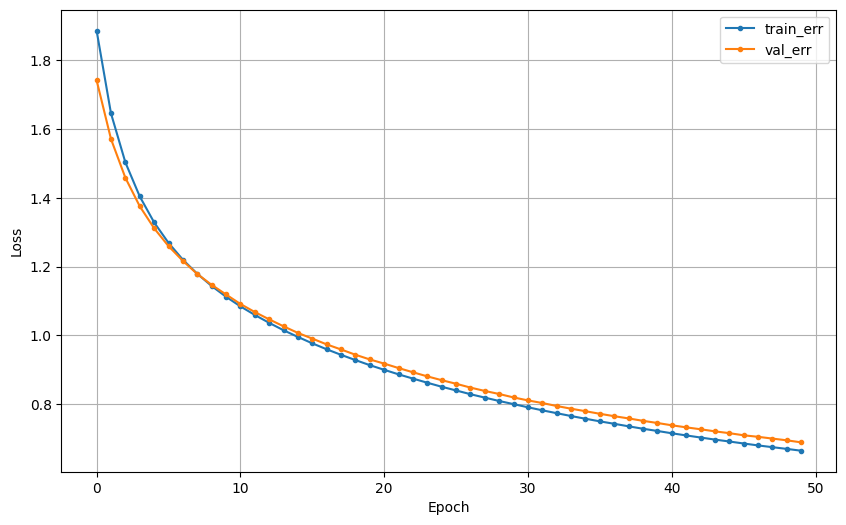

In [39]:
# 학습곡선
dl_history_plot(basic_hist)

In [40]:
# 예측 및 평가
y_pred = basic_model.predict(x_test)
y_pred = y_pred.argmax(axis=1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
[[230   0   0   0   0   1]
 [  1 178  21   0   0   0]
 [  0  22 204   0   0   0]
 [  0   2  13 140  10  33]
 [  0   0   0  13 116  16]
 [  0   5   0  46  12 114]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       0.86      0.89      0.87       200
           2       0.86      0.90      0.88       226
           3       0.70      0.71      0.71       198
           4       0.84      0.80      0.82       145
           5       0.70      0.64      0.67       177

    accuracy                           0.83      1177
   macro avg       0.83      0.82      0.82      1177
weighted avg       0.83      0.83      0.83      1177



### (2) 모델2 : 최소 5개 이상의 은닉층을 추가한 모델

In [42]:
# 모델 설계
clear_session()

nfeatures = x.shape[1]
hidden_model = Sequential([
    Input(shape = (nfeatures, )),
    Dense(256, activation = 'relu'),
    Dense(128, activation = 'relu'),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(16, activation = 'relu'),
    Dense(6, activation = 'softmax')
])

hidden_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,678 (182.34 KB)

 Trainable params: 46,678 (182.34 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# 컴파일 및 학습
hidden_model.compile(optimizer = Adam(learning_rate = 0.001), loss = 'sparse_categorical_crossentropy')

hidden_hist = hidden_model.fit(x_train, y_train, epochs = 50, validation_split = 0.2).history

Epoch 1/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 1.3427 - val_loss: 0.5941
Epoch 2/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4916 - val_loss: 0.4276
Epoch 3/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4331 - val_loss: 0.4342
Epoch 4/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4343 - val_loss: 0.4568
Epoch 5/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4117 - val_loss: 0.3923
Epoch 6/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3679 - val_loss: 0.4067
Epoch 7/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3750 - val_loss: 0.4565
Epoch 8/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3880 - val_loss: 0.3872
Epoch 9/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3751 - val_loss: 0.4427
Epoch 10/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3603 - val_loss: 0.4034
Epoch 11/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3663 - val_loss: 0.4086
Epoch 12/50
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

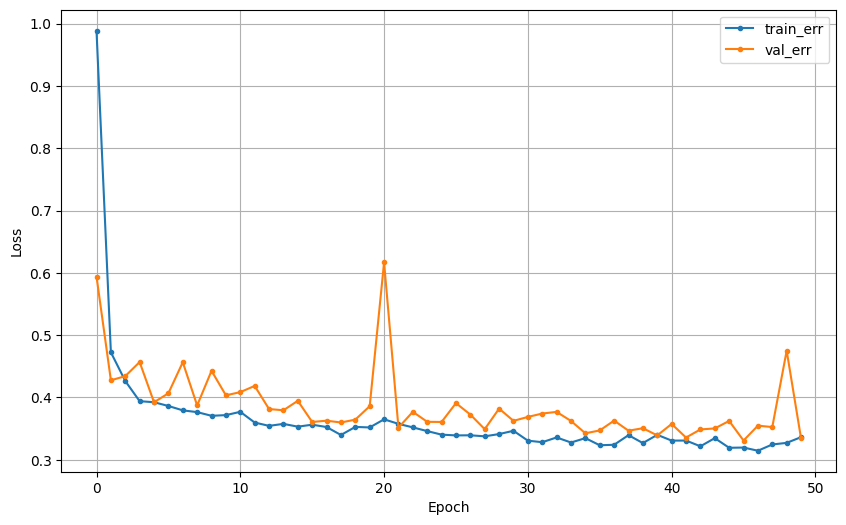

In [44]:
# 학습곡선
dl_history_plot(hidden_hist)

In [45]:
# 예측 및 평가
y_hidden_pred = hidden_model.predict(x_test)
y_hidden_pred = y_hidden_pred.argmax(axis = 1)

print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, zero_division=0))

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
[[230   0   0   0   0   1]
 [  1 178  21   0   0   0]
 [  0  22 204   0   0   0]
 [  0   2  13 140  10  33]
 [  0   0   0  13 116  16]
 [  0   5   0  46  12 114]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       0.86      0.89      0.87       200
           2       0.86      0.90      0.88       226
           3       0.70      0.71      0.71       198
           4       0.84      0.80      0.82       145
           5       0.70      0.64      0.67       177

    accuracy                           0.83      1177
   macro avg       0.83      0.82      0.82      1177
weighted avg       0.83      0.83      0.83      1177



### (3) 모델3 : 학습률, epoch 등 조정

In [46]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

clear_session()

# 개선된 모델
nfeatures = x.shape[1]
improved_model = Sequential([
    Input(shape=(nfeatures, )),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(6, activation='softmax')
])

improved_model.summary()

# 컴파일
improved_model.compile(optimizer = Adam(learning_rate=0.0005), loss='sparse_categorical_crossentropy', metrics=['accuracy']
)

# 콜백 설정
callbacks = [
    EarlyStopping(monitor='val_loss', patience = 15, restore_best_weights = True),
    ReduceLROnPlateau(monitor='val_loss', factor = 0.5, patience=7, min_lr = 0.00001)
]

# 학습
improved_hist = improved_model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64,
    verbose=0
).history

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,086 (711.27 KB)

 Trainable params: 180,294 (704.27 KB)

 Non-trainable params: 1,792 (7.00 KB)

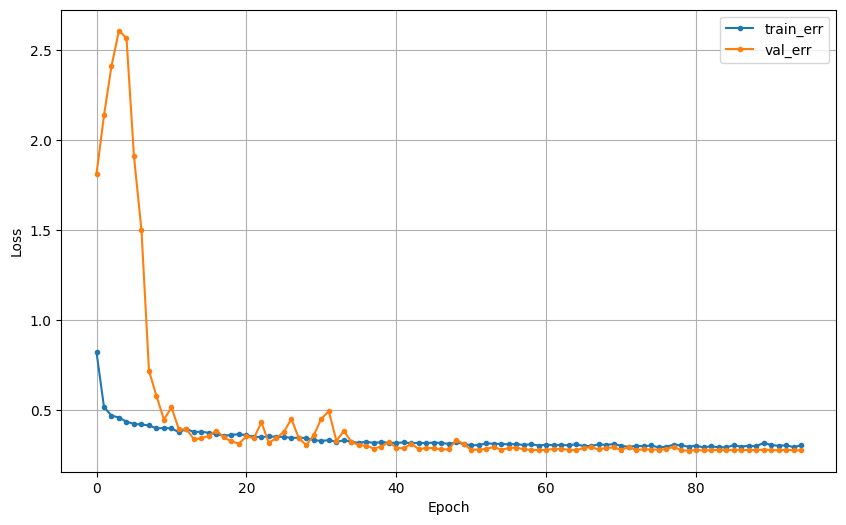

In [47]:
# 학습곡선
dl_history_plot(improved_hist)

In [48]:
# 예측 및 평가
y_improved_pred = improved_model.predict(x_test).argmax(axis=1)
print(confusion_matrix(y_test, y_improved_pred))
print(classification_report(y_test, y_improved_pred, zero_division=0))

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
[[231   0   0   0   0   0]
 [  0 189  11   0   0   0]
 [  0  24 202   0   0   0]
 [  0   0   0 168   7  23]
 [  0   0   0  10 122  13]
 [  0   0   0   8   9 160]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       0.89      0.94      0.92       200
           2       0.95      0.89      0.92       226
           3       0.90      0.85      0.88       198
           4       0.88      0.84      0.86       145
           5       0.82      0.90      0.86       177

    accuracy                           0.91      1177
   macro avg       0.91      0.91      0.91      1177
weighted avg       0.91      0.91      0.91      1177



### (4) 모델4 :  학습률, epoch 등 조정

### (5)베이지안 최적화 적용

In [49]:
!pip install keras-tuner -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 6.6 MB/s eta 0:00:00


In [50]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input

# 1. 하이퍼파라미터를 튜닝할 모델 함수 정의
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(nfeatures,)))

    # 첫 번째 레이어의 유닛 수 튜닝
    model.add(Dense(
        units=hp.Int('units_1', min_value=256, max_value=1024, step=128),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', min_value=0.3, max_value=0.6, step=0.1)))

    # 두 번째 레이어
    model.add(Dense(
        units=hp.Int('units_2', min_value=128, max_value=512, step=64),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', min_value=0.2, max_value=0.5, step=0.1)))

    # 세 번째 레이어
    model.add(Dense(
        units=hp.Int('units_3', min_value=64, max_value=256, step=32),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_3', min_value=0.1, max_value=0.4, step=0.1)))

    # 네 번째 레이어
    model.add(Dense(
        units=hp.Int('units_4', min_value=32, max_value=128, step=16),
        activation='relu'
    ))
    model.add(Dropout(hp.Float('dropout_4', min_value=0.1, max_value=0.3, step=0.1)))

    # 출력 레이어
    model.add(Dense(6, activation='softmax'))

    # Learning rate 튜닝
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4, 5e-4])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    return model

# 2. Bayesian Optimization 튜너 생성
tuner = kt.BayesianOptimization(
    build_model,
    objective='val_accuracy',
    max_trials=30,  # 시도할 조합 수
    executions_per_trial=2,  # 각 조합당 반복 횟수
    directory='bayesian_opt',
    project_name='activity_recognition'
)

# 3. 탐색 시작
tuner.search(
    x_train, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)],
    verbose=1
)

# 4. 최적의 하이퍼파라미터 확인
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\n===== 최적 하이퍼파라미터 =====")
print(f"units_1: {best_hps.get('units_1')}")
print(f"units_2: {best_hps.get('units_2')}")
print(f"units_3: {best_hps.get('units_3')}")
print(f"units_4: {best_hps.get('units_4')}")
print(f"dropout_1: {best_hps.get('dropout_1')}")
print(f"dropout_2: {best_hps.get('dropout_2')}")
print(f"dropout_3: {best_hps.get('dropout_3')}")
print(f"dropout_4: {best_hps.get('dropout_4')}")
print(f"learning_rate: {best_hps.get('learning_rate')}")

# 5. 최적 모델로 재학습
best_model = tuner.hypermodel.build(best_hps)

best_hist = best_model.fit(
    x_train, y_train,
    epochs=100,
    validation_split=0.2,
    callbacks=[
        EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)
    ],
    verbose=1
).history

Reloading Tuner from bayesian_opt/activity_recognition/tuner0.json

===== 최적 하이퍼파라미터 =====
units_1: 384
units_2: 512
units_3: 192
units_4: 112
dropout_1: 0.4
dropout_2: 0.2
dropout_3: 0.1
dropout_4: 0.2
learning_rate: 0.0005


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 384)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 384)            │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 192)            │        98,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 192)            │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 112)            │        21,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 112)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,486 (1.25 MB)

 Trainable params: 324,310 (1.24 MB)

 Non-trainable params: 2,176 (8.50 KB)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 13s 49ms/step - accuracy: 0.6560 - loss: 0.9222 - val_accuracy: 0.1870 - val_loss: 2.1739 - learning_rate: 5.0000e-04
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8199 - loss: 0.4595 - val_accuracy: 0.1870 - val_loss: 2.3381 - learning_rate: 5.0000e-04
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7982 - loss: 0.4884 - val_accuracy: 0.3422 - val_loss: 1.8153 - learning_rate: 5.0000e-04
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8113 - loss: 0.4611 - val_accuracy: 0.6557 - val_loss: 0.7778 - learning_rate: 5.0000e-04
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8277 - loss: 0.4361 - val_accuracy: 0.8385 - val_loss: 0.4491 - learning_rate: 5.0000e-04
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8336 - loss: 0.4032 - val_accuracy: 0.8395 - val_loss: 0.3940 - learning_rate: 5.0000e-04
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - a

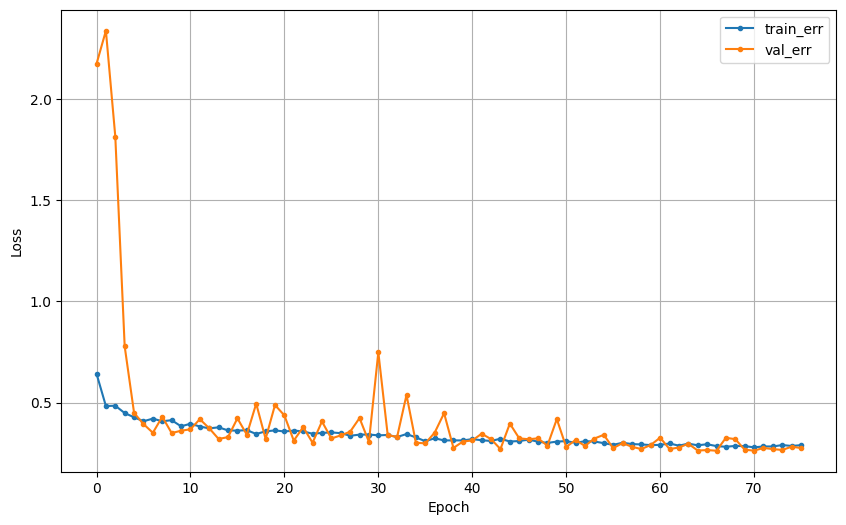

In [51]:
# 학습곡선
dl_history_plot(best_hist)

In [52]:
y_tuned_pred = best_model.predict(x_test).argmax(axis=1)

print(confusion_matrix(y_test, y_tuned_pred))
print(classification_report(y_test, y_tuned_pred, zero_division=0))

37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
[[231   0   0   0   0   0]
 [  0 182  18   0   0   0]
 [  0  16 210   0   0   0]
 [  0   0   0 168   6  24]
 [  0   0   0   9 124  12]
 [  0   0   0   7   9 161]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       231
           1       0.92      0.91      0.91       200
           2       0.92      0.93      0.93       226
           3       0.91      0.85      0.88       198
           4       0.89      0.86      0.87       145
           5       0.82      0.91      0.86       177

    accuracy                           0.91      1177
   macro avg       0.91      0.91      0.91      1177
weighted avg       0.92      0.91      0.91      1177



## 4.성능비교

- test 데이터에 대한 전처리
- 각 모델에 대해서 test 데이터로 성능 측정

In [53]:
# 정수 인코딩 변환(LabelEncoder)

In [54]:
#전체 데이터 불러오기(test)
data01_test = pd.read_csv('data01_test.csv')
# subject 삭제
data01_test.drop('subject', axis = 1, inplace = True)

# x, y 분할
select_features = ['tGravityAcc-min()-X', 'tGravityAcc-min()-Y',
                   'tGravityAcc-energy()-X', 'tGravityAcc-mean()-Y',
                   'tGravityAcc-max()-X', 'angle(X,gravityMean)', 'tBodyAcc-max()-X',
                   'tGravityAcc-max()-Y', 'angle(Y,gravityMean)',
                   'tGravityAcc-mean()-X']

x = data01_test[select_features]
y = data01_test['Activity']

# y : 정수인코딩 적용
y = le.transform(y)

# x : 스케일링 적용
x = scaler.transform(x)

In [55]:
# 정확도
from sklearn.metrics import accuracy_score

### (1)improved_model 결과 확인

In [56]:
y_improved_pred = improved_model.predict(x).argmax(axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [57]:
# 평가
print("===== Test Set 성능 =====")
print(confusion_matrix(y, y_improved_pred))
print()
print(classification_report(y, y_improved_pred, zero_division=0))

print(f"\nTest Accuracy: {accuracy_score(y, y_improved_pred):.4f}")

===== Test Set 성능 =====
[[291   1   0   0   0   0]
 [  0 228  26   0   0   0]
 [  0  51 236   0   0   0]
 [  0   0   0 182   9  37]
 [  0   0   0   6 174  15]
 [  0   0   0  22   5 188]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       292
           1       0.81      0.90      0.85       254
           2       0.90      0.82      0.86       287
           3       0.87      0.80      0.83       228
           4       0.93      0.89      0.91       195
           5       0.78      0.87      0.83       215

    accuracy                           0.88      1471
   macro avg       0.88      0.88      0.88      1471
weighted avg       0.89      0.88      0.88      1471


Test Accuracy: 0.8831


### (2)best_model 결과 확인


In [58]:
# test 데이터에 대한 성능 측정
y_best_pred = best_model.predict(x).argmax(axis=1)

46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


In [59]:
# 평가
print("===== Test Set 성능 =====")
print(confusion_matrix(y, y_best_pred))
print()
print(classification_report(y, y_best_pred, zero_division=0))

# 정확도
from sklearn.metrics import accuracy_score
print(f"\nTest Accuracy: {accuracy_score(y, y_best_pred):.4f}")

===== Test Set 성능 =====
[[290   2   0   0   0   0]
 [  0 224  30   0   0   0]
 [  0  40 247   0   0   0]
 [  0   0   1 186   7  34]
 [  0   0   0   3 174  18]
 [  0   0   0  14   2 199]]

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       292
           1       0.84      0.88      0.86       254
           2       0.89      0.86      0.87       287
           3       0.92      0.82      0.86       228
           4       0.95      0.89      0.92       195
           5       0.79      0.93      0.85       215

    accuracy                           0.90      1471
   macro avg       0.90      0.89      0.90      1471
weighted avg       0.90      0.90      0.90      1471


Test Accuracy: 0.8973
